<a href="https://colab.research.google.com/github/isaacadebayo/Neo4j/blob/main/Neo4j_FIFA_Top_scorer_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install neo4j
!pip install neo4j-driver
!pip install neo4j-python-driver
!pip install neo4j-driver-bolt

ERROR: Could not find a version that satisfies the requirement neo4j-python-driver (from versions: none)
ERROR: No matching distribution found for neo4j-python-driver
ERROR: Could not find a version that satisfies the requirement neo4j-driver-bolt (from versions: none)
ERROR: No matching distribution found for neo4j-driver-bolt


In [21]:
from neo4j import GraphDatabase
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# Connect to your Neo4j instance

# with your actual Neo4j AuraDB connection URI, username, and password.
# Example for AuraDB:

driver = GraphDatabase.driver("neo4j+s://cc5478b8.databases.neo4j.io", auth=("cc5478b8", "NXslhnwzwMhBnRgUl_OzIajAe9eeIHcqwa5QXVZYiGI"))

def run_query(query, parameters=None):
    if parameters is None:
        parameters = {}
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]

# Define file parameters for LOAD CSV

# You must upload your CSV file to a publicly accessible URL (e.g., Google Drive, GitHub Gist) and use that URL here.
# Example: file_path_root = "https://docs.google.com/uc?export=download&id=YOUR_FILE_ID" (for Google Drive direct download link)

file_0 = "" # Set to empty, as file_path_root should be the complete URL to the CSV

# Your Cypher Query - Break into individual statements
query1 = """
LOAD CSV WITH HEADERS FROM $file_path_root AS row
WITH row
CALL {
  WITH row
  MERGE (source: `Player_Name` { `player_name`: row.`player_name` })
  ON CREATE SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`
  ON MATCH SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`

  MERGE (target: `FIFA World Cup` { `PLAYED_AT`: row.`PLAYED_AT` })
  MERGE (source)-[r: `PLAYED_AT`]->(target)
} IN TRANSACTIONS OF 10000 ROWS;
"""

query2 = """
LOAD CSV WITH HEADERS FROM $file_path_root AS row
WITH row
CALL {
  WITH row
  MERGE (source: `Player_Name` { `player_name`: row.`player_name` })
  ON CREATE SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`
  ON MATCH SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`

  MERGE (target: `FIFA World Cup` { `PLAYED_AT`: row.`PLAYED_AT` })
  MERGE (source)-[r: `PLAYED_AT`]->(target)
} IN TRANSACTIONS OF 10000 ROWS;
"""

query3 = """
LOAD CSV WITH HEADERS FROM $file_path_root AS row
WITH row
CALL {
  WITH row
  MERGE (source: `Player_Name` { `player_name`: row.`player_name` })
  ON CREATE SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`
  ON MATCH SET source.`matches` = toInteger(trim(row.`matches`)), source.`goals` = toInteger(trim(row.`goals`)), source.`country` = row.`country`

  MERGE (target: `FIFA World Cup` { `PLAYED_AT`: row.`PLAYED_AT` })
  MERGE (source)-[r: `PLAYED_AT`]->(target)
} IN TRANSACTIONS OF 10000 ROWS;
"""

# Execute each query separately
query_parameters = {"file_path_root": file_path_root, "file_0": file_0}

print("Running query 1...")
run_query(query1, query_parameters)
print("Running query 2...")
run_query(query2, query_parameters)
print("Running query 3...")
run_query(query3, query_parameters)
print("All queries executed.")

Running query 1...


Running query 2...


Running query 3...


All queries executed.


### Visualizing Data from Neo4j

The previous Cypher query was designed for loading data. To visualize data, you typically need to query the data that has already been loaded into your Neo4j database. Here's how you can fetch some data and create a simple visualization.

Query Results:


,Player,Goals
0,Miroslav Klose,16
1,Ronaldo,15
2,Gerd Muller,14
3,Just Fontaine,13
4,Pele,12


/tmp/ipykernel_15945/1612585980.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Player', y='Goals', data=df_players, palette='viridis')


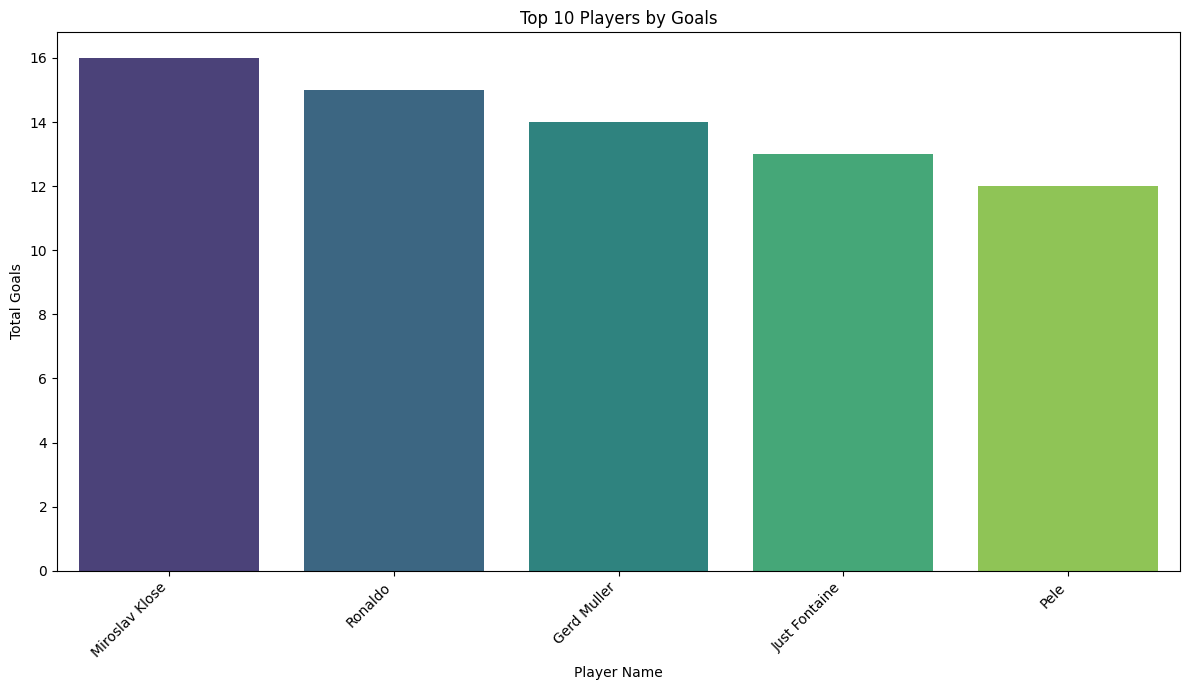

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example Cypher Query to fetch data for visualization
# This assumes you have 'Player_Name' nodes with 'player_name' and 'goals' properties
# Adjust the query based on the actual data you want to visualize.
visualization_query = """
MATCH (p:Player_Name)
RETURN p.player_name AS Player, p.goals AS Goals
ORDER BY Goals DESC
LIMIT 10
"""

# Execute the visualization query
visualization_results = run_query(visualization_query)

# Convert results to a pandas DataFrame
df_players = pd.DataFrame(visualization_results)

if not df_players.empty:
    print("Query Results:")
    display(df_players.head())

    # Visualize the results
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Player', y='Goals', data=df_players, palette='viridis')
    plt.title('Top 10 Players by Goals')
    plt.xlabel('Player Name')
    plt.ylabel('Total Goals')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data returned from the visualization query. Please ensure your Neo4j database has 'Player_Name' nodes with 'goals' properties, or adjust the query.")


In [24]:
# Install networkx for graph visualization
!pip install networkx

# Graph Visualization using networkx

Now, let's query the Neo4j database to retrieve nodes and relationships, and then visualize them using networkx and matplotlib.

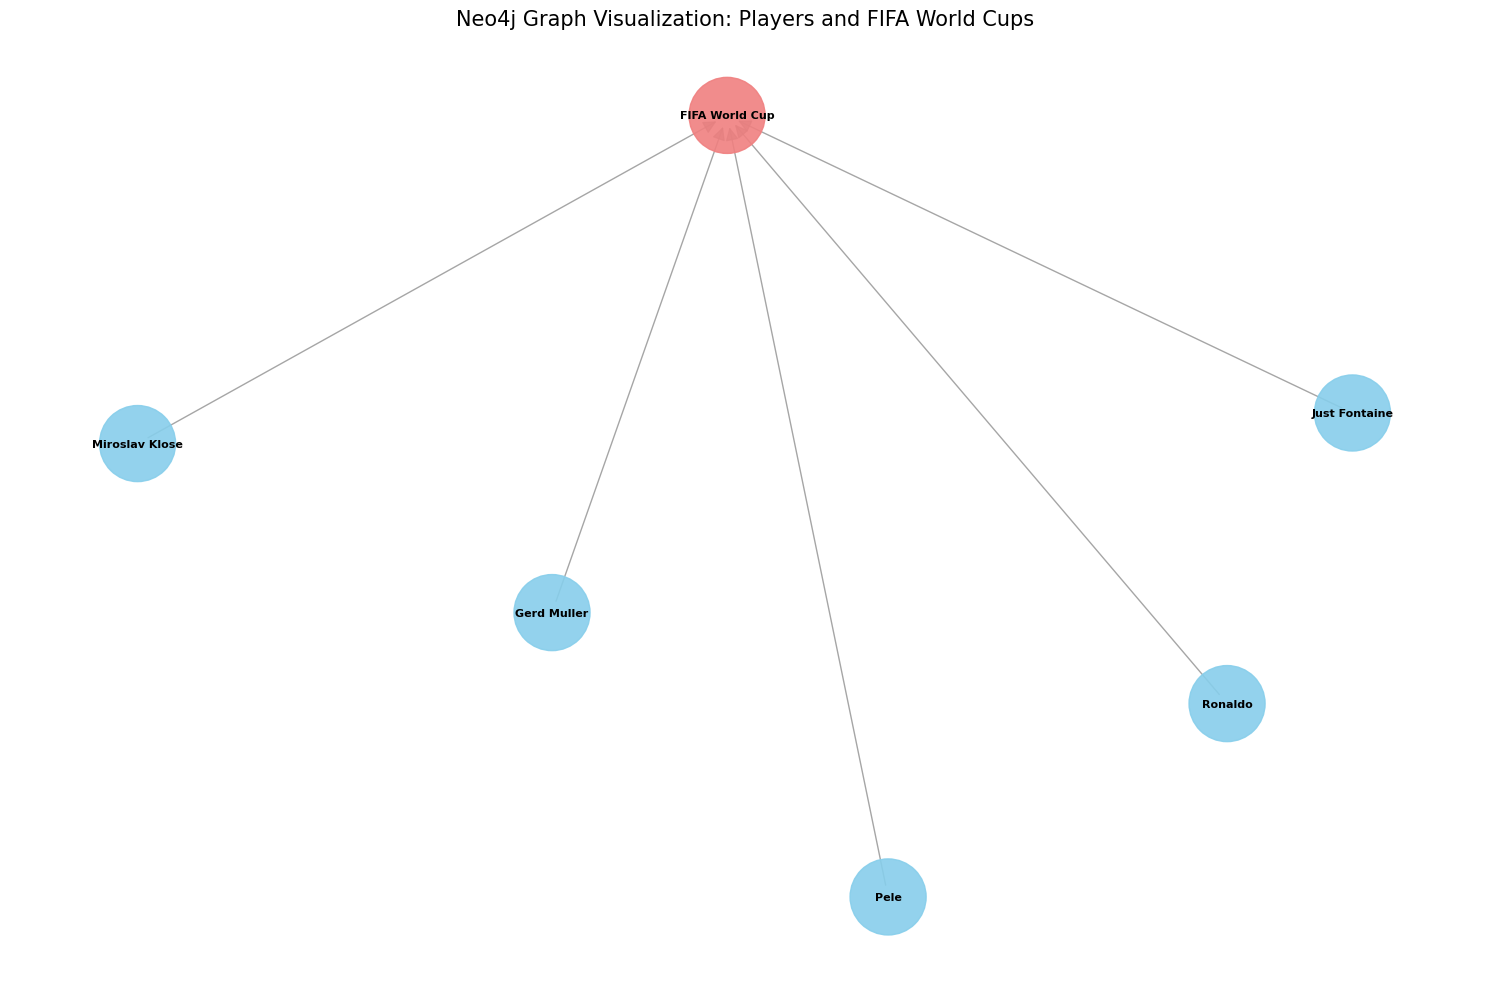

In [25]:
import networkx as nx

# Cypher query to fetch players, World Cups, and their relationships
# We'll limit the number of players for better visualization in a smaller graph.
query_graph = """
MATCH (p:Player_Name)-[r:PLAYED_AT]->(wc:`FIFA World Cup`)
RETURN p.player_name AS player, p.country AS player_country, wc.PLAYED_AT AS world_cup, type(r) AS relationship_type
LIMIT 50
"""

# Execute the query
graph_results = run_query(query_graph)

# Create a directed graph using networkx
G = nx.DiGraph()

player_nodes = set()
world_cup_nodes = set()

for record in graph_results:
    player_name = record['player']
    world_cup = record['world_cup']
    relationship_type = record['relationship_type']

    # Add nodes
    if player_name not in player_nodes:
        G.add_node(player_name, label='Player', country=record['player_country'])
        player_nodes.add(player_name)
    if world_cup not in world_cup_nodes:
        G.add_node(world_cup, label='World Cup')
        world_cup_nodes.add(world_cup)

    # Add edge
    G.add_edge(player_name, world_cup, relation=relationship_type)

# Define node colors based on their type
node_colors = []
for node in G.nodes():
    if G.nodes[node]['label'] == 'Player':
        node_colors.append('skyblue')
    elif G.nodes[node]['label'] == 'World Cup':
        node_colors.append('lightcoral')

# Draw the graph
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.3, iterations=50) # positions for all nodes

# Nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)

# Edges
nx.draw_networkx_edges(G, pos, edgelist=G.edges, edge_color='gray', width=1, arrowsize=20, alpha=0.7)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title('Neo4j Graph Visualization: Players and FIFA World Cups', size=15)
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()